# Grocery Shelf Product Detection

single shot detector for product / no-product detection, one anchor box per feature map cell (3 scales, like ssd/fpn)

In [1]:
# basic imports
# os, json for file handling, random/np/torch for reproducibility
import os, json, random, time, math
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


In [2]:
# fixing seed so result do not change every run
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


In [3]:
# use gpu if available else cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)


using device: cpu


In [4]:
# installation (run once, not every time notebook is run)
# uncomment below line if libraries are not installed already
# !pip -q install torch torchvision pillow numpy matplotlib tqdm --upgrade

In [5]:
# all paths and config at one place so its easy to change
dataset_root = "../dataset"          # change this if dataset is somewhere else
work_dir = "work"
out_dir = os.path.join(work_dir, "outputs")
ckpt_dir = os.path.join(work_dir, "checkpoints")
vis_dir = os.path.join(out_dir, "visualizations")

for d in [work_dir, out_dir, ckpt_dir, vis_dir]:
    os.makedirs(d, exist_ok=True)

img_size = 320
strides = [8, 16, 32]                      # 3 feature map scale, like fpn
grid_sizes = [img_size // s for s in strides]
print("grid size for each stride:", dict(zip(strides, grid_sizes)))

grid size for each stride: {8: 40, 16: 20, 32: 10}


In [6]:
import os
print(os.getcwd())
print(os.path.exists(dataset_root))

C:\Users\kraj\Downloads\data\project\grocery-shelf-product-detector\notebooks
True


## 1. load annotations and images

In [7]:
def find_dir(base, *candidates):
    # dataset folder name can be different (ShelfImages vs shelfimages etc)
    # so just try all possible names and return whichever exist
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.isdir(p):
            return p
    raise FileNotFoundError(f"none of {candidates} found under {base}")

In [8]:
shelf_dir = find_dir(dataset_root, "ShelfImages", "shelfimages", "ShelfImages/ShelfImages")
train_dir = find_dir(shelf_dir, "train", "Train")
test_dir = find_dir(shelf_dir, "test", "Test")

# annotation file name can also differ, checking few common names
annot_path = None
for cand in ["annotation.txt", "annotations.txt", "annotations.csv"]:
    p = os.path.join(dataset_root, cand)
    if os.path.isfile(p):
        annot_path = p
        break
if annot_path is None:
    raise FileNotFoundError("annotation.txt / annotations.csv not found in dataset_root")

print("train dir:", train_dir)
print("test dir :", test_dir)
print("annotation file:", annot_path)

train dir: ../dataset\ShelfImages\train
test dir : ../dataset\ShelfImages\test
annotation file: ../dataset\annotation.txt


In [9]:
def parse_annotation_file(path):
    # format of file: image_name  n_boxes  x1 y1 w1 h1 b1  x2 y2 w2 h2 b2 ...
    # column 3,4 are width and height of box (not bottom right corner)
    # brand id (last number of each box) is not used, we only need product / no product
    annotations = {}
    with open(path, "r") as f:
        for line in f:
            parts = line.strip().replace(",", " ").split()
            if not parts:
                continue
            name = parts[0]
            n_boxes = int(parts[1])
            rest = parts[2:]
            boxes = []
            for i in range(n_boxes):
                x, y, w, h = (float(v) for v in rest[i*5:i*5+4])
                if w > 0 and h > 0:
                    boxes.append([x, y, w, h])
            annotations[name] = boxes
    return annotations

In [10]:
annotations = parse_annotation_file(annot_path)
print("annotation parsed for", len(annotations), "images")

annotation parsed for 354 images


In [11]:
def build_records(image_dir, annotations):
    # this will make list of dict, one dict per image with its path, size and boxes
    records = []
    missing = 0
    for fname in sorted(os.listdir(image_dir)):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        boxes = annotations.get(fname)
        if not boxes:
            # image with no annotation is not useful for training/testing, skip it
            missing += 1
            continue
        path = os.path.join(image_dir, fname)
        with Image.open(path) as im:
            width, height = im.size
        records.append({
            "image_name": fname,
            "image_path": os.path.abspath(path),
            "width": width,
            "height": height,
            "boxes": boxes,
        })
    if missing:
        print(f"  skipped {missing} images in {image_dir}, no annotation found")
    return records

In [12]:
train_records = build_records(train_dir, annotations)
test_records = build_records(test_dir, annotations)

print("train images:", len(train_records), " test images:", len(test_records))
print("train boxes :", sum(len(r["boxes"]) for r in train_records))
print("test boxes  :", sum(len(r["boxes"]) for r in test_records))

train images: 283  test images: 71
train boxes : 10536
test boxes  : 2648


## 2. anchor box (one per scale)

instead of one anchor for full image, we take one anchor per scale (3 total). every gt box is assigned to one scale based on its size, so still only single anchor competes per cell

In [13]:
def box_scale_index(w, h):
    # decide which of the 3 scale this box belong to, based on box size (in 320x320 image)
    size = math.sqrt(max(w * h, 1e-6))
    if size < 40:
        return 0   # stride 8 grid, small product
    elif size < 100:
        return 1   # stride 16 grid, medium product
    else:
        return 2   # stride 32 grid, big product / group of product

In [14]:
def resized_boxes(rec, img_size):
    # boxes are in original image size, we resize them to 320x320 same as image
    sx = img_size / rec["width"]
    sy = img_size / rec["height"]
    return [[x*sx, y*sy, w*sx, h*sy] for (x, y, w, h) in rec["boxes"]]

In [15]:
# collecting all box w,h per scale so we can take median as anchor size
per_scale_boxes = [[], [], []]
for rec in train_records:
    for (x, y, w, h) in resized_boxes(rec, img_size):
        per_scale_boxes[box_scale_index(w, h)].append((w, h))

anchors = []
for s, boxes in enumerate(per_scale_boxes):
    if boxes:
        ws, hs = zip(*boxes)
        aw, ah = float(np.median(ws)), float(np.median(hs))
    else:
        # fallback if no box for this scale (should not normally happen)
        aw, ah = float(img_size / grid_sizes[s]), float(img_size / grid_sizes[s])
    anchors.append((aw, ah))
    print(f"scale stride={strides[s]:>2} grid={grid_sizes[s]}x{grid_sizes[s]} "
          f"n_boxes={len(boxes):>5} anchor=({aw:.1f}, {ah:.1f})")

scale stride= 8 grid=40x40 n_boxes= 8438 anchor=(21.2, 43.4)
scale stride=16 grid=20x20 n_boxes= 2098 anchor=(30.1, 67.9)
scale stride=32 grid=10x10 n_boxes=    0 anchor=(32.0, 32.0)


## 3. target encoding (objectness + box offset for each grid cell)

In [16]:
def encode_targets(boxes, anchors, grid_sizes, img_size):
    # for every scale we make a (grid, grid, 5) array -> [objectness, tx, ty, tw, th]
    # if a cell already has a box (collision) then try next scale before dropping the box
    targets = [np.zeros((g, g, 5), dtype=np.float32) for g in grid_sizes]

    for (x, y, w, h) in boxes:
        cx, cy = x + w / 2.0, y + h / 2.0
        pref_scale = box_scale_index(w, h)
        for s in [pref_scale] + [i for i in range(len(grid_sizes)) if i != pref_scale]:
            grid = grid_sizes[s]
            cell = img_size / grid
            gx, gy = cx / cell, cy / cell
            gi, gj = min(int(gx), grid - 1), min(int(gy), grid - 1)
            if targets[s][gj, gi, 0] == 1:
                # cell already used, try other scale
                continue
            anchor_w, anchor_h = anchors[s]
            tx, ty = gx - gi, gy - gj
            tw, th = math.log(max(w, 1e-3) / anchor_w), math.log(max(h, 1e-3) / anchor_h)
            targets[s][gj, gi] = [1.0, tx, ty, tw, th]
            break
        # if box could not be placed in any scale it is just dropped, very rare case
    return targets

## 4. dataset class and augmentation

In [17]:
class ShelfDataset(Dataset):
    # simple dataset, reads image + boxes and returns tensor + targets for 3 scales
    def __init__(self, records, img_size, anchors, grid_sizes, augment=False):
        self.records = records
        self.img_size = img_size
        self.anchors = anchors
        self.grid_sizes = grid_sizes
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec["image_path"]).convert("RGB").resize((self.img_size, self.img_size))
        boxes = resized_boxes(rec, self.img_size)

        if self.augment:
            img, boxes = self._augment(img, boxes)

        # normalize with imagenet mean/std since backbone is pretrained on imagenet
        img_arr = np.asarray(img, dtype=np.float32) / 255.0
        img_arr = (img_arr - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        img_tensor = torch.from_numpy(img_arr.transpose(2, 0, 1)).float()

        targets = encode_targets(boxes, self.anchors, self.grid_sizes, self.img_size)
        targets = [torch.from_numpy(t) for t in targets]
        return img_tensor, targets[0], targets[1], targets[2]

    def _augment(self, img, boxes):
        # only doing flip and light brightness/contrast change, keeping it simple
        if random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            boxes = [[self.img_size - x - w, y, w, h] for (x, y, w, h) in boxes]
        if random.random() < 0.5:
            from PIL import ImageEnhance
            img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
            img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
        return img, boxes

In [18]:
def collate_fn(batch):
    # combine list of samples into single batch tensor
    imgs = torch.stack([b[0] for b in batch])
    t0 = torch.stack([b[1] for b in batch])
    t1 = torch.stack([b[2] for b in batch])
    t2 = torch.stack([b[3] for b in batch])
    return imgs, [t0, t1, t2]

In [19]:
train_dataset = ShelfDataset(train_records, img_size, anchors, grid_sizes, augment=True)
test_dataset = ShelfDataset(test_records, img_size, anchors, grid_sizes, augment=False)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                           num_workers=0, collate_fn=collate_fn, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)

# just checking one batch shape to be sure everything is fine
imgs, targets = next(iter(train_loader))
print("image batch:", imgs.shape, " target shapes:", [t.shape for t in targets])

image batch: torch.Size([16, 3, 320, 320])  target shapes: [torch.Size([16, 40, 40, 5]), torch.Size([16, 20, 20, 5]), torch.Size([16, 10, 10, 5])]


## 5. model

mobilenetv2 (pretrained on imagenet) as backbone + 3 small head, one for each scale. every head predict 5 number per cell -> [objectness, tx, ty, tw, th], that is single anchor per cell as required

In [20]:
class DetectionHead(nn.Module):
    # small conv head on top of backbone feature map
    def __init__(self, in_ch, mid_ch=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 3, padding=1), nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, mid_ch, 3, padding=1), nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, 5, 1),
        )
        # setting bias of objectness so initial prediction is close to 0 (helps focal loss)
        nn.init.constant_(self.net[-1].bias[0], -4.6)

    def forward(self, x):
        out = self.net(x)               # (batch, 5, h, w)
        return out.permute(0, 2, 3, 1)   # (batch, h, w, 5)

In [21]:
class ProductDetector(nn.Module):
    # layer index of mobilenet where we take feature map, and channel count at that layer
    capture_idxs = {6: 32, 13: 96, 18: 1280}

    def __init__(self, pretrained=True):
        super().__init__()
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.mobilenet_v2(weights=weights).features
        chans = list(self.capture_idxs.values())
        self.heads = nn.ModuleList([DetectionHead(c) for c in chans])

    def forward(self, x):
        feats = []
        capture_set = set(self.capture_idxs.keys())
        out = x
        for idx, layer in enumerate(self.backbone):
            out = layer(out)
            if idx in capture_set:
                feats.append(out)
            if idx == max(capture_set):
                # no need to run rest of backbone, we already got what we need
                break
        return [head(f) for head, f in zip(self.heads, feats)]

In [22]:
model = ProductDetector(pretrained=True).to(device)

# quick sanity check with dummy input
with torch.no_grad():
    dummy = torch.zeros(2, 3, img_size, img_size).to(device)
    outs = model(dummy)
    print("output shape of each scale:", [o.shape for o in outs])

output shape of each scale: [torch.Size([2, 40, 40, 5]), torch.Size([2, 20, 20, 5]), torch.Size([2, 10, 10, 5])]


## 6. loss function

In [23]:
def sigmoid_focal_loss(logits, targets, alpha=0.75, gamma=2.0):
    # focal loss so that easy negative cell (background) does not dominate the loss
    p = torch.sigmoid(logits)
    ce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    p_t = p * targets + (1 - p) * (1 - targets)
    loss = ce * ((1 - p_t) ** gamma)
    alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
    return (alpha_t * loss).sum()

In [24]:
def detection_loss(preds, targets, lambda_coord=2.0):
    # objectness loss (focal) + box regression loss (smooth l1), summed for all 3 scale
    total_obj_loss, total_box_loss, num_pos = 0.0, 0.0, 0
    for pred, target in zip(preds, targets):
        obj_target = target[..., 0]
        obj_logit = pred[..., 0]
        total_obj_loss += sigmoid_focal_loss(obj_logit, obj_target)

        pos_mask = obj_target == 1
        n_pos = pos_mask.sum().item()
        num_pos += n_pos
        if n_pos > 0:
            # box loss only calculated where object is actually present
            box_pred = pred[..., 1:5][pos_mask]
            box_target = target[..., 1:5][pos_mask]
            total_box_loss += F.smooth_l1_loss(box_pred, box_target, reduction="sum")

    denom = max(num_pos, 1)
    return (total_obj_loss + lambda_coord * total_box_loss) / denom

## 7. training

In [25]:
def train_model(model, train_loader, num_epochs, ckpt_dir, out_dir):
    # trains the model and saves best + final checkpoint, also saves loss plot
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    train_losses = []
    best_loss = float("inf")
    start = time.time()

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for imgs, targets in train_loader:
            imgs = imgs.to(device)
            targets = [t.to(device) for t in targets]

            preds = model(imgs)
            loss = detection_loss(preds, targets)

            optimizer.zero_grad()
            loss.backward()
            # clipping gradient so training does not blow up
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            epoch_loss += loss.item() * imgs.size(0)

        scheduler.step()
        epoch_loss /= len(train_loader.dataset)
        train_losses.append(epoch_loss)

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(model.state_dict(), os.path.join(ckpt_dir, "model_best.pth"))

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"epoch {epoch+1:>3}/{num_epochs}  loss={epoch_loss:.4f}  "
                  f"elapsed={time.time()-start:.0f}s")

    torch.save(model.state_dict(), os.path.join(ckpt_dir, "model_final.pth"))
    print("training done, best loss:", best_loss)

    plt.figure(figsize=(6, 4))
    plt.plot(train_losses)
    plt.xlabel("epoch"); plt.ylabel("train loss"); plt.title("training loss")
    plt.savefig(os.path.join(out_dir, "training_loss.png"), dpi=120, bbox_inches="tight")
    plt.show()
    return train_losses

In [26]:
num_epochs = 60
best_ckpt_path = os.path.join(ckpt_dir, "model_best.pth")

# if we already trained the model before, no need to train again, just load it
# this save lot of time when we just want to run evaluation / inference
force_retrain = False   # Note : set False only when you deliberately want to reuse a checkpoint, otherwise True

if os.path.isfile(best_ckpt_path) and not force_retrain:
    print("found saved checkpoint, loading it instead of training again")
    model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
else:
    print("training from scratch")
    train_losses = train_model(model, train_loader, num_epochs, ckpt_dir, out_dir)

found saved checkpoint, loading it instead of training again


## 8. decode prediction + nms

In [27]:
def iou_xywh(box1, box2):
    # standard intersection over union for box in [x, y, w, h] format
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xa, ya = max(x1, x2), max(y1, y2)
    xb, yb = min(x1+w1, x2+w2), min(y1+h1, y2+h2)
    inter = max(0, xb - xa) * max(0, yb - ya)
    union = w1*h1 + w2*h2 - inter
    return inter / union if union > 0 else 0.0

In [28]:
def nms(boxes, scores, iou_thresh=0.45):
    # simple greedy non max suppression, single class so no need to group by class
    idxs = np.argsort(scores)[::-1]
    keep = []
    while len(idxs) > 0:
        current = idxs[0]
        keep.append(current)
        rest = idxs[1:]
        idxs = np.array([i for i in rest if iou_xywh(boxes[current], boxes[i]) < iou_thresh])
    return keep

In [29]:
def decode(preds, anchors, grid_sizes, img_size, conf_thresh=0.3):
    # preds is list of 3 tensor (h, w, 5) for one single image, no batch dim here
    all_boxes, all_scores = [], []
    for pred, (anchor_w, anchor_h), grid in zip(preds, anchors, grid_sizes):
        cell = img_size / grid
        obj = torch.sigmoid(pred[..., 0])
        mask = obj > conf_thresh
        if mask.sum() == 0:
            continue
        idxs = mask.nonzero(as_tuple=False)
        for gj, gi in idxs.tolist():
            score = obj[gj, gi].item()
            tx, ty, tw, th = pred[gj, gi, 1:5].tolist()
            cx, cy = (gi + tx) * cell, (gj + ty) * cell
            w, h = math.exp(tw) * anchor_w, math.exp(th) * anchor_h
            all_boxes.append([cx - w/2, cy - h/2, w, h])
            all_scores.append(score)

    if not all_boxes:
        return [], []
    all_boxes, all_scores = np.array(all_boxes), np.array(all_scores)
    keep = nms(all_boxes, all_scores, iou_thresh=0.45)
    return all_boxes[keep].tolist(), all_scores[keep].tolist()

In [30]:
@torch.no_grad()
def run_inference(model, image_path, img_size, anchors, grid_sizes, conf_thresh=0.3):
    # runs model on single image and return decoded boxes + score
    img = Image.open(image_path).convert("RGB")
    img_r = img.resize((img_size, img_size))
    arr = np.asarray(img_r, dtype=np.float32) / 255.0
    arr = (arr - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    tensor = torch.from_numpy(arr.transpose(2, 0, 1)).float().unsqueeze(0).to(device)

    model.eval()
    preds = model(tensor)
    preds = [p[0].cpu() for p in preds]
    boxes, scores = decode(preds, anchors, grid_sizes, img_size, conf_thresh)
    return boxes, scores

## 9. evaluation - mAP, precision, recall

single class problem so mAP is just AP. we sweep threshold to get full pr curve for mAP, and also find best threshold (by f1) for precision/recall reporting

In [31]:
def collect_test_predictions(model, records, img_size, anchors, grid_sizes, conf_thresh=0.05):
    # low threshold here so we get full score range to sweep over later
    all_preds = []   # each item: (image_index, score, box)
    gts = []          # ground truth box per image
    model.eval()
    with torch.no_grad():
        for i, rec in enumerate(records):
            boxes, scores = run_inference(model, rec["image_path"], img_size, anchors, grid_sizes, conf_thresh)
            for b, s in zip(boxes, scores):
                all_preds.append((i, s, b))
            gts.append(resized_boxes(rec, img_size))
    return all_preds, gts

In [32]:
def compute_ap(all_preds, gts, iou_thresh=0.5):
    # standard voc style average precision
    all_preds = sorted(all_preds, key=lambda x: -x[1])
    n_gt = sum(len(g) for g in gts)
    matched = [np.zeros(len(g), dtype=bool) for g in gts]
    tp, fp = np.zeros(len(all_preds)), np.zeros(len(all_preds))

    for k, (img_idx, score, box) in enumerate(all_preds):
        gt_boxes = gts[img_idx]
        best_iou, best_j = 0.0, -1
        for j, gt in enumerate(gt_boxes):
            if matched[img_idx][j]:
                continue
            i = iou_xywh(box, gt)
            if i > best_iou:
                best_iou, best_j = i, j
        if best_iou >= iou_thresh and best_j >= 0:
            tp[k] = 1
            matched[img_idx][best_j] = True
        else:
            fp[k] = 1

    tp_cum, fp_cum = np.cumsum(tp), np.cumsum(fp)
    recall = tp_cum / max(n_gt, 1)
    precision = tp_cum / np.maximum(tp_cum + fp_cum, 1e-9)

    # precision envelope (making precision monotonically decreasing) then area under curve
    mrec = np.concatenate([[0.0], recall, [1.0]])
    mpre = np.concatenate([[0.0], precision, [0.0]])
    for i in range(len(mpre)-2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i+1])
    idxs = np.where(mrec[1:] != mrec[:-1])[0]
    ap = float(np.sum((mrec[idxs+1] - mrec[idxs]) * mpre[idxs+1]))
    return ap, precision, recall

In [40]:
def best_f1_operating_point(all_preds, gts, iou_thresh=0.5, thresholds=None):
    # find confidence threshold which gives best f1 score
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)
    best = {"f1": -1}
    for t in thresholds:
        filtered = [p for p in all_preds if p[1] >= t]
        n_gt = sum(len(g) for g in gts)
        matched = [np.zeros(len(g), dtype=bool) for g in gts]
        tp = fp = 0
        for img_idx, score, box in sorted(filtered, key=lambda x: -x[1]):
            gt_boxes = gts[img_idx]
            best_iou, best_j = 0.0, -1
            for j, gt in enumerate(gt_boxes):
                if matched[img_idx][j]:
                    continue
                i = iou_xywh(box, gt)
                if i > best_iou:
                    best_iou, best_j = i, j
            if best_iou >= iou_thresh and best_j >= 0:
                tp += 1
                matched[img_idx][best_j] = True
            else:
                fp += 1
        fn = n_gt - tp
        precision = tp / max(tp+fp, 1e-9)
        recall = tp / max(tp+fn, 1e-9)
        f1 = 2*precision*recall / max(precision+recall, 1e-9)
        if f1 > best["f1"]:
            best = {"f1": f1, "threshold": float(t), "precision": precision, "recall": recall}
    return best

map = 0.9966
best operating point = {'f1': 0.9841628959276018, 'threshold': 0.25, 'precision': 0.9826807228915663, 'recall': 0.9856495468277946}
{
    "mAP": 0.9966,
    "precision": 0.9827,
    "recall": 0.9856
}


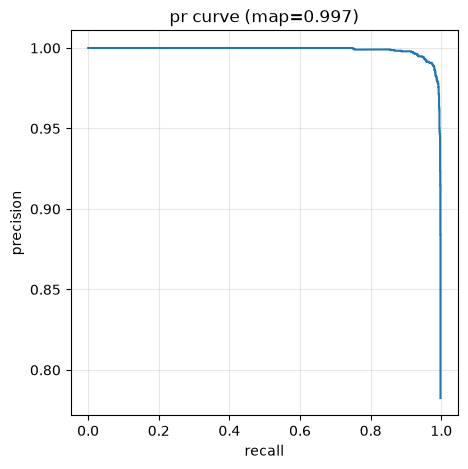

In [41]:
# loading best checkpoint before evaluating (in case we just trained above)
model.load_state_dict(torch.load(best_ckpt_path, map_location=device))

all_preds, gts = collect_test_predictions(model, test_records, img_size, anchors, grid_sizes)
map_score, pr_precision, pr_recall = compute_ap(all_preds, gts, iou_thresh=0.5)
best_op = best_f1_operating_point(all_preds, gts, iou_thresh=0.5)

print(f"map = {map_score:.4f}")
print(f"best operating point = {best_op}")

metrics = {
    "mAP": round(map_score, 4),
    "precision": round(best_op["precision"], 4),
    "recall": round(best_op["recall"], 4),
}
with open(os.path.join(out_dir, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)
print(json.dumps(metrics, indent=4))

plt.figure(figsize=(5, 5))
plt.plot(pr_recall, pr_precision)
plt.xlabel("recall"); plt.ylabel("precision"); plt.title(f"pr curve (map={map_score:.3f})")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(out_dir, "pr_curve.png"), dpi=120, bbox_inches="tight")
plt.show()

## 10. image2products.json

In [42]:
def build_image2products(model, records, img_size, anchors, grid_sizes, conf_thresh):
    # for every test image, count how many product box model predicted
    result = {}
    for rec in records:
        boxes, scores = run_inference(model, rec["image_path"], img_size, anchors, grid_sizes, conf_thresh)
        result[rec["image_name"]] = len(boxes)
    return result

In [43]:
conf_thresh = best_op["threshold"]

image_to_products = build_image2products(model, test_records, img_size, anchors, grid_sizes, conf_thresh)

with open(os.path.join(out_dir, "image2products.json"), "w") as f:
    json.dump(image_to_products, f, indent=4)

print("saved image2products.json for", len(image_to_products), "images")
list(image_to_products.items())[:5]

saved image2products.json for 71 images


[('C1_P02_N1_S5_1.JPG', 49),
 ('C1_P02_N2_S2_1.JPG', 24),
 ('C1_P02_N2_S3_1.JPG', 30),
 ('C1_P03_N1_S2_1.JPG', 29),
 ('C1_P03_N1_S3_1.JPG', 45)]

## 11. visualize prediction on 50 test image

In [44]:
def draw_boxes(image_path, boxes, img_size, color="lime"):
    # just draws rectangle on image for every predicted box
    img = Image.open(image_path).convert("RGB").resize((img_size, img_size))
    draw = ImageDraw.Draw(img)
    for (x, y, w, h) in boxes:
        draw.rectangle([x, y, x+w, y+h], outline=color, width=2)
    return img

saved 50 annotated images to work\outputs\visualizations


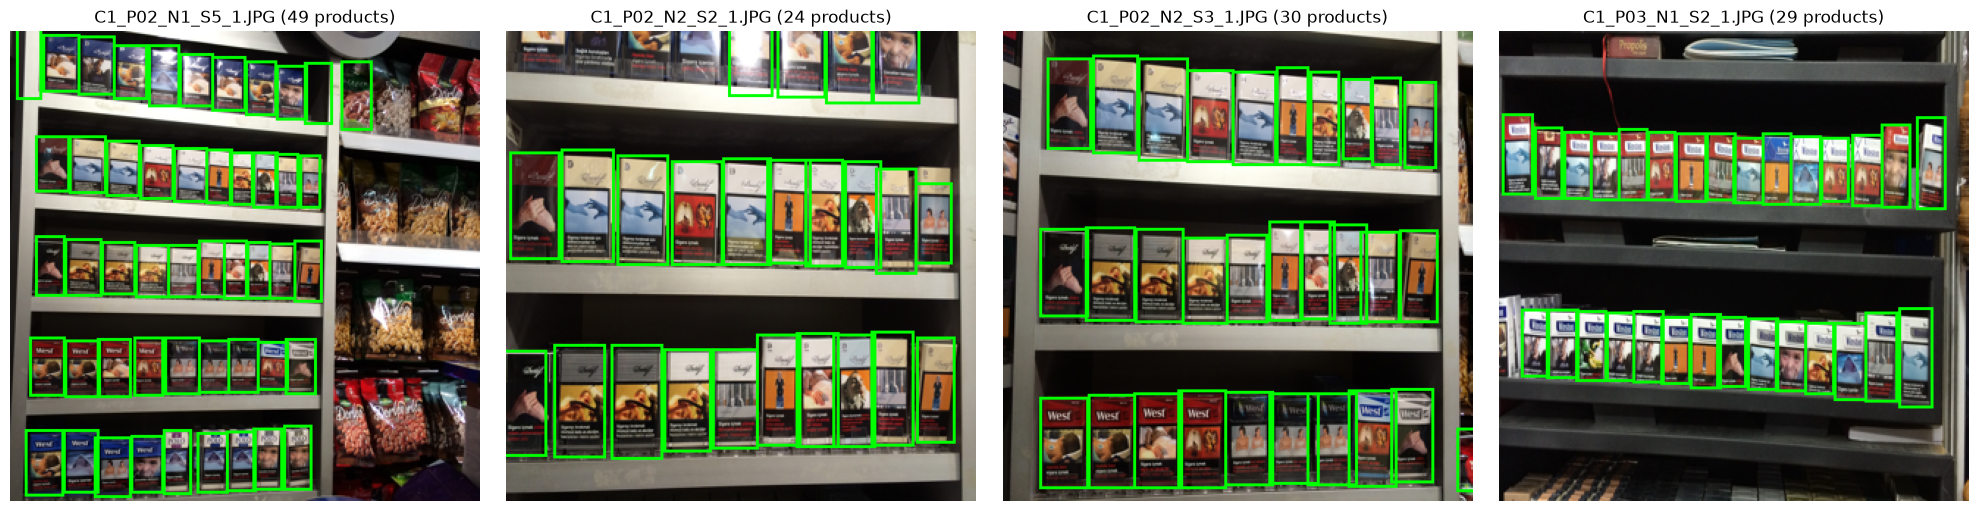

In [45]:
sample_records = test_records[:50] if len(test_records) >= 50 else test_records

for rec in sample_records:
    boxes, scores = run_inference(model, rec["image_path"], img_size, anchors, grid_sizes, conf_thresh)
    vis = draw_boxes(rec["image_path"], boxes, img_size)
    vis.save(os.path.join(vis_dir, rec["image_name"]))

print(f"saved {len(sample_records)} annotated images to {vis_dir}")

# just a quick look at few images here in notebook itself
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, rec in zip(axes, sample_records[:4]):
    boxes, scores = run_inference(model, rec["image_path"], img_size, anchors, grid_sizes, conf_thresh)
    vis = draw_boxes(rec["image_path"], boxes, img_size)
    ax.imshow(vis)
    ax.set_title(f"{rec['image_name']} ({len(boxes)} products)")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [46]:
inference_config = {
    "img_size": img_size,
    "strides": strides,
    "grid_sizes": grid_sizes,
    "anchors": anchors,
}
with open(os.path.join(ckpt_dir, "config.json"), "w") as f:
    json.dump(inference_config, f, indent=2)

print("saved config.json next to model_best.pth")

saved config.json next to model_best.pth
